In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch
from einops import repeat
from scipy import stats
from sklearn.decomposition import PCA
import pandas as pd
import subprocess as sp
import re
import random

# from models.airfoil_MLP import EDM_CFG, VP_1D, ProbabilityFlowODE, Airfoil1D_Dataset, edm_sampler, StackedRandomGenerator
from models.diffusion_model import EDM_CFG, edm_sampler, StackedRandomGenerator


def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

In [2]:
df = pd.read_csv("aerofoil_data.csv")

In [ ]:
def parse_array_from_string(s):
    # Remove brackets and split by whitespace
    s = s.strip().replace("[","").replace("]","")
    return np.array([float(v) for v in s.split()], dtype=float)

cols_to_normalize = ['y', 'Ma', 'Re', 'AOA', 'CL', 'CD']

max_values={}
min_values={}

for col in cols_to_normalize:
    if col == 'y':
        # Convert each row to a numeric array
        df[col] = df[col].apply(lambda x: parse_array_from_string(x) if isinstance(x, str) else np.array(x, dtype=float))

        # Compute global min and max across all y elements
        y_max = df[col].apply(np.max).max()
        y_min = df[col].apply(np.min).min()

        # Normalize
        df[col] = df[col].apply(lambda arr: (arr - y_min) / (y_max - y_min))
        
        max_values[col] = y_max
        min_values[col] = y_min
    else:
        col_min = df[col].min()
        col_max = df[col].max()
        df[col] = (df[col] - col_min) / (col_max - col_min)
        max_values[col] = col_max
        min_values[col] = col_min

print(max_values)
print(min_values)

In [5]:
def xfoil_calculation(x,y,AOA,Re,Ma,CL,CD):
    
    geom_file_name = f'generated_geom/profile_{AOA:.1f}_{Ma:.1f}_{int(Re)}_{CL:.1f}_{CD:.1f}'
    result_file_name = f'generated_data/profile_{AOA:.1f}_{Ma:.1f}_{int(Re)}_{CL:.1f}_{CD:.1f}'
    xfoilpath = '/home/yg1922/Desktop/Xfoil_2/bin/xfoil'

    with open(f'{geom_file_name}', "w") as f:
        f.write(f'generated_profile_{AOA:.1f}_{Ma:.1f}_{int(Re)}_{CL:.2f}_{CD:.2f}' + "\n")  # First line
    
        for xi, yi in zip(x, y):
            f.write(f"{xi} {yi}\n")

    # Delete the previous run results
    for f in [result_file_name]:
        try:
            os.remove(f)
        except FileNotFoundError:
            pass

    def Xfoil(Ma, Re):
        xfoil_commands = f"""
            PLOP
            G F

            LOAD {geom_file_name}

            OPER
            ITER 500
            MACH {Ma}
            VISC {Re}
            PACC
            {result_file_name}

            ALFA {AOA}

            QUIT
            """

        try:
            ps = sp.Popen([xfoilpath],
                        stdin=sp.PIPE,
                        stdout=sp.PIPE,
                        stderr=sp.PIPE)

            stdout, stderr = ps.communicate(input=xfoil_commands.encode(), timeout = 10)

            ps.stdin.close()
            ps.stdout.close()
            ps.stderr.close()

        except sp.TimeoutExpired:
            print('error in ', geom_file_name)
            ps.kill()
            print('Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.')
            # if os.path.exists(result_file_name): 
            #     os.remove(result_file_name)
            

        except Exception as e:
            print(f"Error running {geom_file_name}: {e}")
            print('Something unexpected happened')
            ps.kill()

    Xfoil(Ma=Ma, Re=Re)


    f = open(result_file_name, 'r', errors='ignore')
    flines = f.readlines()


    if len(flines) != 12: 
        for i in range(12, len(flines)):
            words = str.split(flines[i]) 
            CL_actual    = float(words[1])
            CD_actual    = float(words[2])
            LD_r  = float(words[1]) / float(words[2])
    else:
        print('There is no output from xfoil. Possibly because the profile generated is not feasible.')
        CL_actual = 999
        CD_actual = 999
    return CL_actual, CD_actual

In [23]:
def validation_plot(model,  sample_size, data_structure, device, database, pca = None):
    plt.rcdefaults()
    model.eval()
    df = database
    numbers = random.sample(range(0, len(df['name'])), sample_size)

    for i in numbers:
        
        x_str = df.loc[i, 'x']
        x_str = re.sub(r'[\[\]]', '', x_str)   # remove brackets
        x_coords_original = [float(v) for v in x_str.split()]
        
        y_str = df.loc[i, 'y']
        y_str = re.sub(r'[\[\]]', '', y_str)   # remove brackets
        y_coords_original = np.array([float(v) for v in y_str.split()])
        y_coords_original = y_coords_original * (y_max - y_min) + y_min


        name = df.loc[i,'name']
        Ma = df.loc[i, 'Ma']
        Re = df.loc[i, 'Re']
        AOA = df.loc[i, 'AOA']
        CL = df.loc[i, 'CL']
        CD = df.loc[i, 'CD']

        
        # denormalise the condition data
        actual_Ma = Ma*(max_values['Ma']-min_values['Ma'])+min_values['Ma']
        actual_Re = Re*(max_values['Re']-min_values['Re'])+min_values['Re']
        actual_AOA = AOA*(max_values['AOA']-min_values['AOA'])+min_values['AOA']
        actual_CL = CL*(max_values['CL']-min_values['CL'])+min_values['CL']
        actual_CD = CD*(max_values['CD']-min_values['CD'])+min_values['CD']

        # convert the condition data into a tensor
        cond = (torch.tensor([Ma, Re, AOA, CL, CD]).to(device))

        # use the model to generate coordinates
        rnd = StackedRandomGenerator(device, range(1))
        latents = rnd.randn([1, model.in_dim], device=device)
        with torch.no_grad():
            samples, _ = edm_sampler(model, latents=latents, class_labels=cond, randn_like=rnd.randn_like, deterministic=True) 
        samples = samples.float()
        sample = samples[0].cpu().numpy()
        
        if data_structure == 'pca':
            sample = pca.inverse_transform(sample)


        # denormalise the generated coordinates
        x_coords = sample[0::2]
        y_coords_normalised = sample[1::2]
        y_coords = y_coords_normalised*(y_max - y_min)+y_min

        # xfoil to calculate the data for the genrated design
        CL_actual, CD_actual = xfoil_calculation(x_coords, y_coords, actual_AOA, actual_Re, actual_Ma, actual_CL, actual_CD)

        # Plotting function
        fig, ax = plt.subplots()
        ax.grid(True, ls=':')
        ax.plot(x_coords,y_coords, color = 'b', label = 'generated')
        ax.plot(x_coords_original,y_coords_original, color = 'r', label = 'original')
        ax.set_ylim(-0.4,0.4)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(
                f"{name} \n"
                f"Ma: {actual_Ma:.1f} "
                f"Re: {int(actual_Re)} "
                f"AOA: {int(actual_AOA)} deg \n"
                f"Intended CD: {actual_CD:.2f} "
                f"Intended CL: {actual_CL:.2f} \n"
                f"Actual CD: {CD_actual:.2f} "
                f"Actual CL: {CL_actual:.2f} "
                )
        ax.legend()
    plt.show()

In [24]:
def test_plot(AOA, Ma, Re, CL, CD, data_structure, model, device, pca=None):
    
    plt.rcdefaults()
    model.eval()
    
    normalised_Ma = (Ma-min_values['Ma'])/(max_values['Ma']-min_values['Ma'])
    normalised_Re = (Re-min_values['Re'])/(max_values['Re']-min_values['Re'])
    normalised_AOA = (AOA-min_values['AOA'])/(max_values['AOA']-min_values['AOA'])
    normalised_CL = (CL-min_values['CL'])/(max_values['CL']-min_values['CL'])
    normalised_CD = (CD-min_values['CD'])/(max_values['CD']-min_values['CD'])


    cond = (torch.tensor([normalised_Ma, normalised_Re, normalised_AOA, normalised_CL, normalised_CD]).to(device))
    rnd = StackedRandomGenerator(device, range(1))
    latents = rnd.randn([1, model.in_dim], device=device)
    
    with torch.no_grad():
        samples, _ = edm_sampler(model, latents=latents, class_labels=cond, randn_like=rnd.randn_like, deterministic=True) 
    
    samples = samples.float()
    sample = samples[0].cpu().numpy()
    
    if data_structure == 'pca':
        sample = pca.inverse_transform(sample)

    x_coords = sample[0::2]
    y_coords_normalised = sample[1::2]
    y_coords = y_coords_normalised*(y_max - y_min)+y_min

    CL_actual, CD_actual = xfoil_calculation(x_coords, y_coords, AOA, Re, Ma, CL, CD)

    fig, ax = plt.subplots()
    ax.grid(True, ls=':')
    ax.plot(x_coords,y_coords, color = 'b', label = 'generated')
    ax.set_ylim(-0.4,0.4)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(
            f"Ma: {Ma:.1f} "
            f"Re: {int(Re)} "
            f"AOA: {int(AOA)} deg \n"
            f"Intended CD: {CD:.2f} "
            f"Intended CL: {CL:.2f} \n"
            f"Actual CD: {CD_actual:.2f} "
            f"Actual CL: {CL_actual:.2f} ")
    
    ax.legend()
    plt.show()

In [29]:
def model_deployment(mode, data_structure, sample_number=1, AOA=None, Ma=None, Re=None, CL=None, CD=None):
    
    df = pd.read_csv("aerofoil_data_normalised.csv")

    if data_structure == 'pca':
        num_components = 20

        combined_coordinates = []
        cond_data = []
        for _, row in df.iterrows():
            x_coords = np.fromstring(row["x"].strip("[]"), sep=" ")
            y_coords = np.fromstring(row["y"].strip("[]"), sep=" ")
            paired = np.column_stack((x_coords, y_coords)).flatten()
            combined_coordinates.append(paired)
        coordinates = np.array(combined_coordinates)
        pca = PCA(n_components=num_components)
        coordinates = pca.fit_transform(coordinates)

        model = EDM_CFG(num_components, num_components, cond_size=5, model_dim=128,
                dim_mult=[1,2,2], dim_mult_emb=4, num_blocks=2,
                dropout=0, emb_type="sinusoidal", dim_mult_time=1, model_type='MLP',
                dim_mult_cond=1, cond_drop_prob=0, adaptive_scale=True, skip_scale=1.0, affine=True)

        model.load_state_dict(torch.load('mdl_weight/edm_2.pth'))


    elif data_structure == 'raw_coords':
        num_components = 600
        
        model = EDM_CFG(num_components, num_components, cond_size=5, model_dim=128,
                dim_mult=[1,2,2], dim_mult_emb=4, num_blocks=10,
                dropout=0, emb_type="sinusoidal", dim_mult_time=1, model_type='Conv_1D',
                dim_mult_cond=1, cond_drop_prob=0, adaptive_scale=True, skip_scale=1.0, affine=True)
        pca = None
        model.load_state_dict(torch.load('mdl_weight/test.pth'))
    

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    if mode == 'validation':
        validation_plot(model, sample_number, data_structure, device, df, pca)
    elif mode == 'test':
        test_plot(AOA, Ma, Re, CL, CD, data_structure, model, device, pca)

Total parameters: 3,624,084
error in  generated_geom/profile_2.0_0.2_200000_0.5_0.0
Take too long for xfoil to run on this profile. Possibly because the profile generated is not feasible.
There is no output from xfoil. Possibly because the profile generated is not feasible.


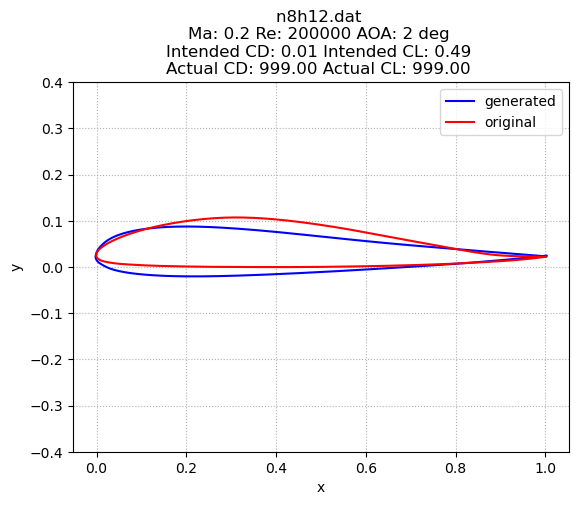

In [31]:
model_deployment(mode = 'validation', data_structure='pca', sample_number=1, AOA=None, Ma=None, Re=None, CL=None, CD=None)

Total parameters: 22,311,042


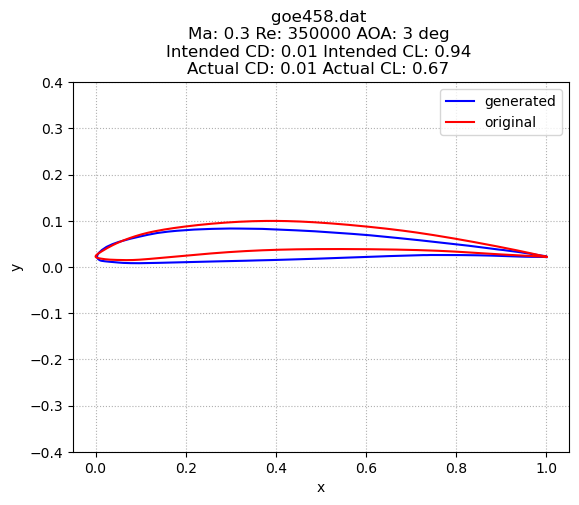

In [32]:
model_deployment(mode = 'validation', data_structure='raw_coords', sample_number=1, AOA=None, Ma=None, Re=None, CL=None, CD=None)

hihihi
Total parameters: 22,311,042


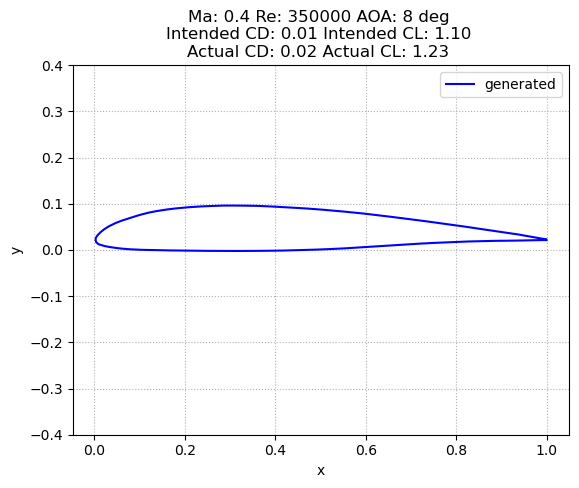

In [130]:
model_deployment(mode = 'test', data_structure='raw_coords', sample_number=None, AOA=8, Ma=0.4, Re=350000, CL=1.1, CD=0.01)